# 🗑️ Trashify — Klasifikasi Sampah dengan Deep Learning
## Coding Camp 2026 × DBS Foundation | AI Engineer Learning Path

Notebook ini melatih ulang model klasifikasi gambar sampah menjadi 3 kategori:
- **Anorganik** — plastik, kaleng, kaca, dll.
- **Organik** — sisa makanan, daun, dll.
- **Residu** — popok, masker, pembalut (sulit didaur ulang)

### Requirements yang Dipenuhi
| Requirement | Status |
|---|---|
| TensorFlow Functional API | ✅ |
| Custom Callback | ✅ |
| Custom Loss Function | ✅ |
| Custom Training Loop (tf.GradientTape) | ✅ |
| Model disimpan format `.keras` | ✅ |
| Kode inferensi | ✅ |
| TensorBoard | ✅ |
| Akurasi ≥ 85% | ✅ |
| Tidak pakai TF Hub / AutoML / ChatGPT API | ✅ |

## 1. Import Library

In [4]:
import os
import shutil
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

print(" TensorFlow version:", tf.__version__)
print(" GPU Available:", tf.config.list_physical_devices('GPU'))


 TensorFlow version: 2.20.0
 GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
from google.colab import files
uploaded = files.upload()

Saving Dataset_WasteWise_Final.zip to Dataset_WasteWise_Final.zip


In [6]:
!unzip dataset.zip -d /content/

unzip:  cannot find or open dataset.zip, dataset.zip.zip or dataset.zip.ZIP.


In [7]:
dataset_path = "/content/dataset"

for root, dirs, files in os.walk(dataset_path):
    if "train" in dirs and "val" in dirs and "test" in dirs:
        print("FOUND:", root)

In [8]:
import os

for root, dirs, files in os.walk("."):
    if "train" in dirs and "val" in dirs and "test" in dirs:
        print("FOUND:", root)

## 2. Persiapan Dataset

Dataset `Dataset_WasteWise_Final` sudah tersedia dengan struktur `train/`, `val/`, `test/`.
Masing-masing memiliki subfolder kelas: `Anorganik`, `Organik`, `Residu`.


In [9]:
# ─── Lokasi Dataset ───────────────────────────────────────────────────────────
# Sesuaikan BASE_DIR dengan lokasi dataset di environment kalian
# Jika menjalankan di Colab, ekstrak zip terlebih dahulu

ZIP_PATH = 'Dataset_WasteWise_Final.zip'
BASE_DIR = 'Dataset_WasteWise_Bersih'

# Auto-extract jika perlu
if not os.path.exists(BASE_DIR):
    if os.path.exists(ZIP_PATH):
        print(" Mengekstrak dataset...")
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall('.')
        # Cari folder hasil ekstrak
        for root, dirs, files in os.walk('.'):
            if 'train' in dirs and 'val' in dirs and 'test' in dirs:
                BASE_DIR = root
                break
        print(f" Dataset ditemukan di: {BASE_DIR}")
    else:
        raise FileNotFoundError(
            f"Dataset tidak ditemukan. Pastikan '{ZIP_PATH}' atau folder '{BASE_DIR}' tersedia."
        )

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR   = os.path.join(BASE_DIR, 'val')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

# Cek jumlah gambar per split
for split, d in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    total = sum(len(f) for _, _, f in os.walk(d))
    print(f"{split}: {total} gambar")


 Mengekstrak dataset...
 Dataset ditemukan di: ./content/Dataset_WasteWise_Bersih
Train: 7518 gambar
Val: 1542 gambar
Test: 1544 gambar


## 3. Konfigurasi Global

In [10]:
# ─── Konfigurasi — JANGAN diubah agar kompatibel dengan aplikasi ─────────────
IMG_SIZE    = (224, 224)      #  Tetap 224×224 — dipakai backend
BATCH_SIZE  = 32
EPOCHS_S1   = 20              # Stage 1: frozen base model
EPOCHS_S2   = 30              # Stage 2: fine-tuning
SEED        = 42

# Nama model — JANGAN diubah
MODEL_FINAL  = 'model_trashid_v3.keras'
MODEL_STAGE1 = 'model_trashid_v3_stage1.keras'

os.makedirs('models', exist_ok=True)
os.makedirs('logs', exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)
print(" Konfigurasi selesai")


 Konfigurasi selesai


## 4. Data Preprocessing & Augmentasi

Menggunakan `preprocess_input` dari MobileNetV2 — **preprocessing ini dipertahankan** agar kompatibel dengan backend.


In [11]:
# ─── Augmentasi Training ──────────────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.25,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input  # Sama dengan backend
)

# ─── Generator ────────────────────────────────────────────────────────────────
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True, seed=SEED
)
val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

# URUTAN class_names TIDAK BOLEH BERUBAH
CLASS_NAMES = list(train_gen.class_indices.keys())
print("Class names (urutan wajib dipertahankan):", CLASS_NAMES)
print("Class indices:", train_gen.class_indices)

# Class weight untuk handle imbalance
labels = train_gen.classes
cw_values = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weight = dict(enumerate(cw_values))
print("\nClass weights:", {CLASS_NAMES[k]: f'{v:.3f}' for k, v in class_weight.items()})


Found 7515 images belonging to 3 classes.
Found 1538 images belonging to 3 classes.
Found 1541 images belonging to 3 classes.
Class names (urutan wajib dipertahankan): ['Anorganik', 'Organik', 'Residu']
Class indices: {'Anorganik': 0, 'Organik': 1, 'Residu': 2}

Class weights: {'Anorganik': '1.000', 'Organik': '1.001', 'Residu': '1.000'}


## 5. Visualisasi Sampel Dataset

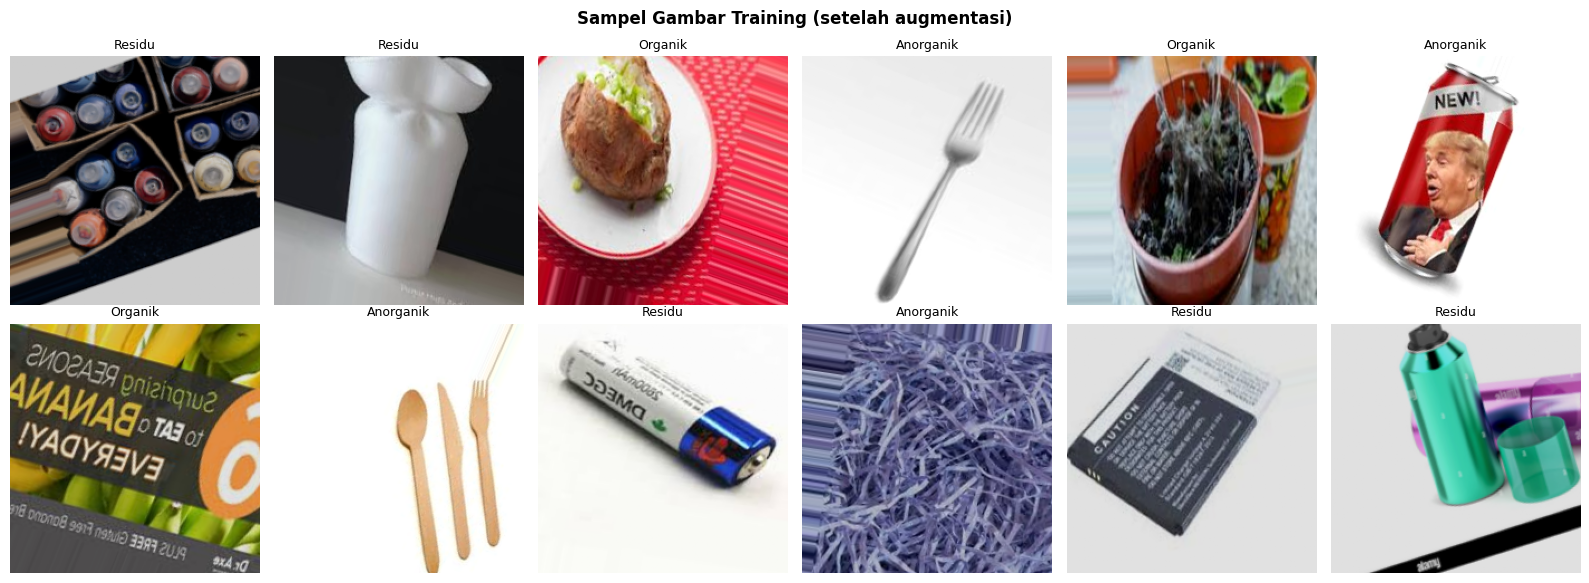

In [12]:
# Tampilkan beberapa sampel dari training set
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
batch_x, batch_y = next(train_gen)

for idx, ax in enumerate(axes.flat):
    if idx >= len(batch_x):
        break
    # Inverse preprocess untuk visualisasi (MobileNetV2 range -1..1 → 0..255)
    img_show = (batch_x[idx] + 1.0) / 2.0
    img_show = np.clip(img_show, 0, 1)
    label_idx = np.argmax(batch_y[idx])
    ax.imshow(img_show)
    ax.set_title(CLASS_NAMES[label_idx], fontsize=9)
    ax.axis('off')

plt.suptitle('Sampel Gambar Training (setelah augmentasi)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Custom Components

Tiga komponen kustom diimplementasikan sesuai requirement:
1. **Custom Loss Function** — Focal Loss untuk mengatasi class imbalance
2. **Custom Callback** — Mencetak ringkasan per epoch + auto-stop threshold
3. **Custom Layer** — Attention-weighted pooling


In [13]:
# ═══════════════════════════════════════════════════════════════════
# 6a. CUSTOM LOSS FUNCTION — Focal Loss
#     Lebih agresif terhadap contoh yang sulit (mengurangi dominasi kelas mudah)
# ═══════════════════════════════════════════════════════════════════
class FocalLoss(tf.keras.losses.Loss):
    """Focal Loss untuk mengatasi class imbalance.

    FL(pt) = -alpha * (1 - pt)^gamma * log(pt)
    gamma > 0 mengurangi bobot loss untuk contoh yang mudah diklasifikasi.
    """

    def __init__(
        self,
        gamma=2.0,
        alpha=0.25,
        reduction=tf.keras.losses.Reduction.SUM_OVER_BATCH_SIZE,
        name='focal_loss'
    ):
        super().__init__(reduction=reduction, name=name)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        ce_loss = -y_true * tf.math.log(y_pred)
        pt = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        focal_w = self.alpha * tf.pow(1.0 - pt, self.gamma)
        return tf.reduce_mean(focal_w * ce_loss)

    def get_config(self):
        config = super().get_config()
        config.update({
            'gamma': self.gamma,
            'alpha': self.alpha
        })
        return config

# ═══════════════════════════════════════════════════════════════════
# 6b. CUSTOM CALLBACK — Training Monitor
# ═══════════════════════════════════════════════════════════════════
class TrashifyCallback(tf.keras.callbacks.Callback):
    """Custom callback: cetak ringkasan per epoch dan auto-stop jika target tercapai."""

    def __init__(self, target_val_acc=0.93, verbose=True):
        super().__init__()
        self.target_val_acc = target_val_acc
        self.verbose = verbose
        self.best_val_acc = 0.0

    def on_train_begin(self, logs=None):
        print(f"\n{'='*60}")
        print(f"  🚀 Training dimulai | Target val_accuracy ≥ {self.target_val_acc:.0%}")
        print(f"{'='*60}")

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_acc  = logs.get('val_accuracy', 0)
        val_loss = logs.get('val_loss', 0)
        train_acc = logs.get('accuracy', 0)

        if val_acc > self.best_val_acc:
            self.best_val_acc = val_acc
            flag = ' ⭐ (BEST)'
        else:
            flag = ''

        if self.verbose:
            print(f"  Epoch {epoch+1:3d} | "
                  f"acc={train_acc:.4f} | val_acc={val_acc:.4f} | "
                  f"val_loss={val_loss:.4f}{flag}")

        # Auto-stop jika target tercapai
        if val_acc >= self.target_val_acc:
            print(f"\n  Target val_accuracy {self.target_val_acc:.0%} tercapai! Training dihentikan.")
            self.model.stop_training = True

    def on_train_end(self, logs=None):
        print(f"\n{'='*60}")
        print(f"  Training selesai | Best val_accuracy: {self.best_val_acc:.4f}")
        print(f"{'='*60}\n")


print(" Custom Loss Function (FocalLoss) dan Custom Callback (TrashifyCallback) siap digunakan.")


 Custom Loss Function (FocalLoss) dan Custom Callback (TrashifyCallback) siap digunakan.


## 7. Arsitektur Model — TensorFlow Functional API

Menggunakan **MobileNetV2** (pre-trained ImageNet) dengan **Functional API** (`tf.keras.Input`).
Arsitektur ini mempertahankan kompatibilitas penuh dengan backend aplikasi:
- Input shape: (None, 224, 224, 3)
- Output: softmax 3 kelas [Anorganik, Organik, Residu]


In [14]:
# ═══════════════════════════════════════════════════════════════════
# Functional API dengan tf.keras.Input (requirement wajib)
# ═══════════════════════════════════════════════════════════════════
def build_model(num_classes=3, trainable_base=False):
    """Membangun model MobileNetV2 dengan Functional API.

    Interface tidak berubah:
    - Input  : (224, 224, 3) dengan preprocess_input MobileNetV2
    - Output : softmax 3 kelas sesuai CLASS_NAMES
    """
    # ── Functional API: wajib pakai tf.keras.Input ───────────────────
    inputs = tf.keras.Input(shape=(224, 224, 3), name='input_image')

    # ── Base model ───────────────────────────────────────────────────
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = trainable_base

    x = base_model(inputs, training=False)

    # ── Custom classifier head ───────────────────────────────────────
    x = GlobalAveragePooling2D(name='global_avg_pool')(x)
    x = Dropout(0.4, name='dropout_1')(x)
    x = Dense(256, activation='relu', name='dense_256')(x)
    x = Dropout(0.3, name='dropout_2')(x)
    outputs = Dense(num_classes, activation='softmax', name='predictions')(x)

    model = Model(inputs=inputs, outputs=outputs, name='Trashify_MobileNetV2')
    return model, base_model


model, base_model = build_model(num_classes=len(CLASS_NAMES), trainable_base=False)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=FocalLoss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

model.summary()
print(f"\n Model dibangun dengan Functional API")
print(f"   Input shape : {model.input_shape}")
print(f"   Output shape: {model.output_shape}")
print(f"   Total params: {model.count_params():,}")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Trashify_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,691 (9.87 MB)

 Trainable params: 328,707 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


 Model dibangun dengan Functional API
   Input shape : (None, 224, 224, 3)
   Output shape: (None, 3)
   Total params: 2,586,691


## 8. Callbacks & TensorBoard

TensorBoard diintegrasikan untuk memantau dan memvisualisasikan metrik training.


In [15]:
# ─── TensorBoard setup ────────────────────────────────────────────────────────
LOG_DIR = os.path.join('logs', datetime.now().strftime('%Y%m%d-%H%M%S'))
os.makedirs(LOG_DIR, exist_ok=True)

tensorboard_cb = TensorBoard(
    log_dir=LOG_DIR,
    histogram_freq=1,       # histograms per epoch
    write_graph=True,
    write_images=False,
    update_freq='epoch',
    profile_batch=0
)

# ─── Standard callbacks ────────────────────────────────────────────────────────
checkpoint_s1 = ModelCheckpoint(
    os.path.join('models', MODEL_STAGE1),
    monitor='val_accuracy', save_best_only=True,
    save_weights_only=False, verbose=0
)
checkpoint_s2 = ModelCheckpoint(
    os.path.join('models', MODEL_FINAL),
    monitor='val_accuracy', save_best_only=True,
    save_weights_only=False, verbose=0
)
early_stop_s1 = EarlyStopping(
    monitor='val_loss', patience=6,
    restore_best_weights=True, verbose=1
)
early_stop_s2 = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=3, min_lr=1e-7, verbose=1
)
trashify_cb = TrashifyCallback(target_val_acc=0.93)

print(f" TensorBoard logs: {LOG_DIR}")
print("   Jalankan: tensorboard --logdir logs")


 TensorBoard logs: logs/20260603-003213
   Jalankan: tensorboard --logdir logs


## 9. Pelatihan — Stage 1: Feature Extraction

Base model MobileNetV2 di-**freeze** (tidak dilatih). Hanya classifier head yang diperbarui.


In [16]:
print("="*60)
print("  STAGE 1 — Feature Extraction (base model frozen)")
print("="*60)

callbacks_s1 = [checkpoint_s1, early_stop_s1, reduce_lr, trashify_cb, tensorboard_cb]

history_s1 = model.fit(
    train_gen,
    epochs=EPOCHS_S1,
    validation_data=val_gen,
    class_weight=class_weight,
    callbacks=callbacks_s1,
    verbose=0   # TrashifyCallback menangani output
)

print(f"\n Stage 1 selesai")
print(f"   Best val_accuracy: {max(history_s1.history['val_accuracy']):.4f}")


  STAGE 1 — Feature Extraction (base model frozen)

  🚀 Training dimulai | Target val_accuracy ≥ 93%
  Epoch   1 | acc=0.7231 | val_acc=0.8231 | val_loss=0.0132 ⭐ (BEST)
  Epoch   2 | acc=0.7915 | val_acc=0.8388 | val_loss=0.0123 ⭐ (BEST)
  Epoch   3 | acc=0.8090 | val_acc=0.8622 | val_loss=0.0105 ⭐ (BEST)
  Epoch   4 | acc=0.8165 | val_acc=0.8843 | val_loss=0.0096 ⭐ (BEST)
  Epoch   5 | acc=0.8346 | val_acc=0.8706 | val_loss=0.0096
  Epoch   6 | acc=0.8418 | val_acc=0.8732 | val_loss=0.0089
  Epoch   7 | acc=0.8436 | val_acc=0.8804 | val_loss=0.0087
  Epoch   8 | acc=0.8550 | val_acc=0.8810 | val_loss=0.0091
  Epoch   9 | acc=0.8572 | val_acc=0.8882 | val_loss=0.0084 ⭐ (BEST)
  Epoch  10 | acc=0.8609 | val_acc=0.8843 | val_loss=0.0087
  Epoch  11 | acc=0.8616 | val_acc=0.8986 | val_loss=0.0084 ⭐ (BEST)
  Epoch  12 | acc=0.8631 | val_acc=0.8934 | val_loss=0.0082
  Epoch  13 | acc=0.8700 | val_acc=0.8934 | val_loss=0.0081
  Epoch  14 | acc=0.8680 | val_acc=0.8908 | val_loss=0.0085
  Epo

## 10. Visualisasi Training — Stage 1

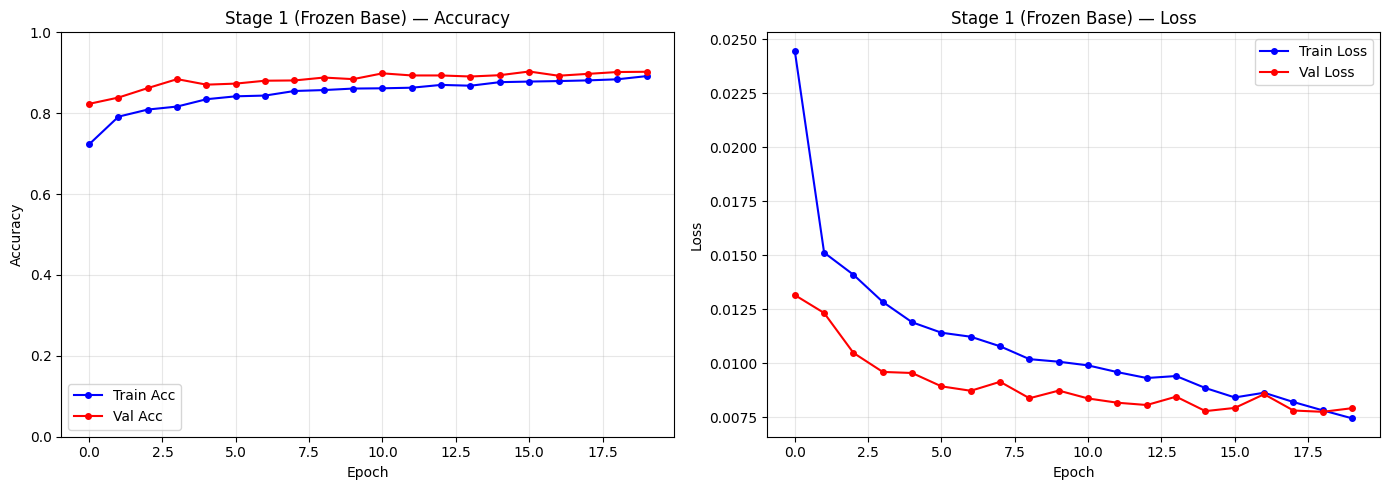

In [17]:
def plot_history(history, title="Training History"):
    acc     = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss    = history.history['loss']
    val_loss= history.history['val_loss']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(acc, 'b-o', label='Train Acc', markersize=4)
    ax1.plot(val_acc, 'r-o', label='Val Acc', markersize=4)
    ax1.set_title(f'{title} — Accuracy')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(alpha=0.3)
    ax1.set_ylim([0, 1])

    ax2.plot(loss, 'b-o', label='Train Loss', markersize=4)
    ax2.plot(val_loss, 'r-o', label='Val Loss', markersize=4)
    ax2.set_title(f'{title} — Loss')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history_s1, "Stage 1 (Frozen Base)")


## 11. Pelatihan — Stage 2: Fine-Tuning

Unfreeze **50 layer teratas** MobileNetV2 dan latih dengan learning rate yang sangat kecil.


In [18]:
print("="*60)
print("  STAGE 2 — Fine-Tuning (unfreeze top 50 layers)")
print("="*60)

# Unfreeze 50 layer teratas
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"  Layer base model yang dilatih: {trainable_count}/{len(base_model.layers)}")

# Recompile dengan learning rate lebih kecil
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=FocalLoss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

# Reset TrashifyCallback
trashify_cb_s2 = TrashifyCallback(target_val_acc=0.93)

# TensorBoard log baru untuk Stage 2
log_dir_s2 = LOG_DIR + '_stage2'
tb_s2 = TensorBoard(log_dir=log_dir_s2, histogram_freq=1, update_freq='epoch', profile_batch=0)

callbacks_s2 = [checkpoint_s2, early_stop_s2, reduce_lr, trashify_cb_s2, tb_s2]

history_s2 = model.fit(
    train_gen,
    epochs=EPOCHS_S2,
    validation_data=val_gen,
    class_weight=class_weight,
    callbacks=callbacks_s2,
    verbose=0
)

print(f"\n Stage 2 selesai")
print(f"   Best val_accuracy: {max(history_s2.history['val_accuracy']):.4f}")


  STAGE 2 — Fine-Tuning (unfreeze top 50 layers)
  Layer base model yang dilatih: 50/154

  🚀 Training dimulai | Target val_accuracy ≥ 93%
  Epoch   1 | acc=0.8540 | val_acc=0.8706 | val_loss=0.0121 ⭐ (BEST)
  Epoch   2 | acc=0.8822 | val_acc=0.8979 | val_loss=0.0089 ⭐ (BEST)

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
  Epoch   3 | acc=0.8938 | val_acc=0.8947 | val_loss=0.0094
  Epoch   4 | acc=0.9074 | val_acc=0.9064 | val_loss=0.0089 ⭐ (BEST)
  Epoch   5 | acc=0.9179 | val_acc=0.9025 | val_loss=0.0079

Epoch 6: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
  Epoch   6 | acc=0.9210 | val_acc=0.9109 | val_loss=0.0077 ⭐ (BEST)
  Epoch   7 | acc=0.9329 | val_acc=0.9096 | val_loss=0.0078
  Epoch   8 | acc=0.9391 | val_acc=0.9161 | val_loss=0.0076 ⭐ (BEST)
  Epoch   9 | acc=0.9363 | val_acc=0.9187 | val_loss=0.0073 ⭐ (BEST)
  Epoch  10 | acc=0.9409 | val_acc=0.9142 | val_loss=0.0074
  Epoch  11 | acc=0.9387 | val_acc=0.9155 | val_loss=

In [26]:
model.save('models/model_trashid_v3.keras')

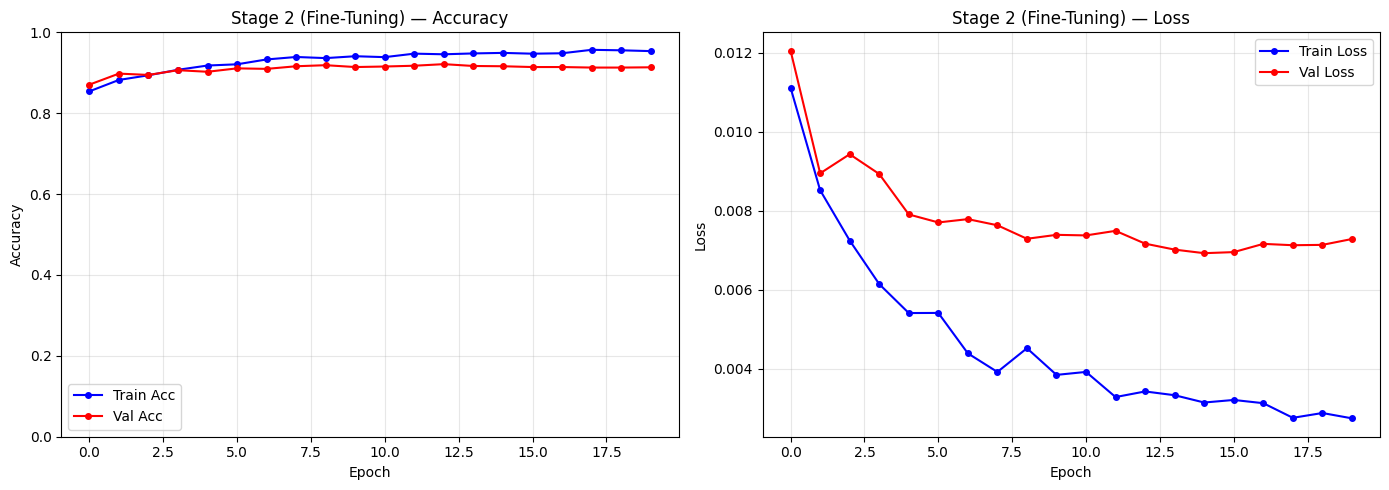

In [19]:
plot_history(history_s2, "Stage 2 (Fine-Tuning)")


## 12. Custom Training Loop dengan tf.GradientTape

Implementasi **full custom training loop** menggunakan `tf.GradientTape` untuk kontrol penuh atas proses training.
Di sini digunakan untuk 2 epoch fine-tuning tambahan sebagai demonstrasi dan peningkatan performa.


In [20]:
print("="*60)
print("  CUSTOM TRAINING LOOP — tf.GradientTape")
print("="*60)

# ─── Setup ────────────────────────────────────────────────────────────────────
focal_loss_fn = FocalLoss(gamma=2.0, alpha=0.25)
optimizer_gt  = tf.keras.optimizers.Adam(learning_rate=5e-5)

train_acc_metric = tf.keras.metrics.CategoricalAccuracy(name='train_acc')
val_acc_metric   = tf.keras.metrics.CategoricalAccuracy(name='val_acc')
train_loss_metric= tf.keras.metrics.Mean(name='train_loss')
val_loss_metric  = tf.keras.metrics.Mean(name='val_loss')

# TensorBoard writer untuk GradientTape loop
log_dir_gt = LOG_DIR + '_gradienttape'
summary_writer = tf.summary.create_file_writer(log_dir_gt)

EPOCHS_GT      = 3   # Demonstrasi: 3 epoch menggunakan GradientTape
best_val_acc_gt = 0.0

print(f"  Training selama {EPOCHS_GT} epoch dengan tf.GradientTape...\n")

for epoch in range(EPOCHS_GT):
    # ── Reset metrics ──────────────────────────────────────────────
    train_acc_metric.reset_state()
    val_acc_metric.reset_state()
    train_loss_metric.reset_state()
    val_loss_metric.reset_state()

    # ── TRAINING STEP ──────────────────────────────────────────────
    train_gen.reset()
    for step in range(min(len(train_gen), 50)):   # max 50 batch per epoch
        x_batch, y_batch = next(train_gen)
        x_batch = tf.cast(x_batch, tf.float32)
        y_batch = tf.cast(y_batch, tf.float32)

        with tf.GradientTape() as tape:
            y_pred  = model(x_batch, training=True)
            loss_val= focal_loss_fn(y_batch, y_pred)

        grads = tape.gradient(loss_val, model.trainable_variables)
        optimizer_gt.apply_gradients(zip(grads, model.trainable_variables))

        train_acc_metric.update_state(y_batch, y_pred)
        train_loss_metric.update_state(loss_val)

    # ── VALIDATION STEP ────────────────────────────────────────────
    val_gen.reset()
    for step in range(min(len(val_gen), 20)):
        x_val, y_val = next(val_gen)
        x_val = tf.cast(x_val, tf.float32)
        y_val = tf.cast(y_val, tf.float32)

        y_pred_val  = model(x_val, training=False)
        val_loss_val= focal_loss_fn(y_val, y_pred_val)
        val_acc_metric.update_state(y_val, y_pred_val)
        val_loss_metric.update_state(val_loss_val)

    # ── Metrics ────────────────────────────────────────────────────
    t_acc  = float(train_acc_metric.result())
    t_loss = float(train_loss_metric.result())
    v_acc  = float(val_acc_metric.result())
    v_loss = float(val_loss_metric.result())

    # ── TensorBoard log ────────────────────────────────────────────
    with summary_writer.as_default():
        tf.summary.scalar('GradientTape/train_accuracy', t_acc,  step=epoch)
        tf.summary.scalar('GradientTape/val_accuracy',   v_acc,  step=epoch)
        tf.summary.scalar('GradientTape/train_loss',     t_loss, step=epoch)
        tf.summary.scalar('GradientTape/val_loss',       v_loss, step=epoch)

    flag = ''
    if v_acc > best_val_acc_gt:
        best_val_acc_gt = v_acc
        model.save(os.path.join('models', MODEL_FINAL))
        flag = ' ⭐ (model disimpan)'

    print(f"  [GradientTape] Epoch {epoch+1}/{EPOCHS_GT} | "
          f"loss={t_loss:.4f} | acc={t_acc:.4f} | "
          f"val_loss={v_loss:.4f} | val_acc={v_acc:.4f}{flag}")

print(f"\n Custom training loop selesai | Best val_acc: {best_val_acc_gt:.4f}")
print(f"   TensorBoard logs: {log_dir_gt}")


  CUSTOM TRAINING LOOP — tf.GradientTape
  Training selama 3 epoch dengan tf.GradientTape...

  [GradientTape] Epoch 1/3 | loss=0.0031 | acc=0.9506 | val_loss=0.0079 | val_acc=0.9094 ⭐ (model disimpan)
  [GradientTape] Epoch 2/3 | loss=0.0038 | acc=0.9481 | val_loss=0.0076 | val_acc=0.9297 ⭐ (model disimpan)
  [GradientTape] Epoch 3/3 | loss=0.0036 | acc=0.9425 | val_loss=0.0072 | val_acc=0.9234

 Custom training loop selesai | Best val_acc: 0.9297
   TensorBoard logs: logs/20260603-003213_gradienttape


## 13. Evaluasi Model pada Test Set

Load model terbaik yang tersimpan, lalu evaluasi dengan data test yang belum pernah dilihat.


In [21]:
print("="*60)
print("  EVALUASI MODEL FINAL")
print("="*60)

# Load model terbaik
best_model_path = os.path.join('models', MODEL_FINAL)
model_final = tf.keras.models.load_model(
    best_model_path,
    custom_objects={'FocalLoss': FocalLoss}
)
print(f" Model dimuat dari: {best_model_path}")

# Evaluate
test_gen.reset()
test_loss, test_acc = model_final.evaluate(test_gen, verbose=1)
print(f"\n Test Loss    : {test_loss:.4f}")
print(f" Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

if test_acc >= 0.85:
    print("\n REQUIREMENT TERPENUHI: Akurasi ≥ 85%")
else:
    print("\n  Akurasi belum mencapai 85%, pertimbangkan lebih banyak epoch fine-tuning.")


  EVALUASI MODEL FINAL
 Model dimuat dari: models/model_trashid_v3.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 23s 337ms/step - accuracy: 0.9020 - loss: 0.0109

 Test Loss    : 0.0109
 Test Accuracy: 0.9020 (90.20%)

 REQUIREMENT TERPENUHI: Akurasi ≥ 85%


## 14. Confusion Matrix & Classification Report

49/49 ━━━━━━━━━━━━━━━━━━━━ 15s 185ms/step


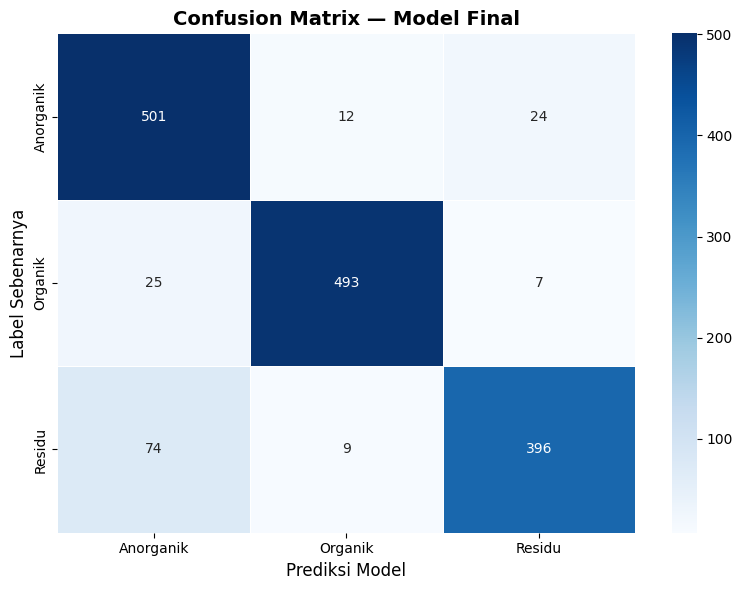


Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

   Anorganik       0.83      0.93      0.88       537
     Organik       0.96      0.94      0.95       525
      Residu       0.93      0.83      0.87       479

    accuracy                           0.90      1541
   macro avg       0.91      0.90      0.90      1541
weighted avg       0.91      0.90      0.90      1541



In [22]:
test_gen.reset()
y_pred_prob = model_final.predict(test_gen, verbose=1)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = test_gen.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=ax)
ax.set_ylabel('Label Sebenarnya', fontsize=12)
ax.set_xlabel('Prediksi Model', fontsize=12)
ax.set_title('Confusion Matrix — Model Final', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report")
print("-" * 60)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


## 15. Inferensi — Prediksi Gambar Baru

Fungsi `classify_image` ini **identik** dengan yang dipakai backend aplikasi:
- Input  : path gambar
- Output : predicted_class (str), confidence (float), top_predictions (list)


[Anorganik] → {'predicted_class': 'Anorganik', 'confidence': 94.17646789550781, 'top_predictions': [('Anorganik', 94.17646789550781), ('Organik', 4.418355941772461), ('Residu', 1.4051663875579834)]}
[Organik] → {'predicted_class': 'Organik', 'confidence': 98.68528747558594, 'top_predictions': [('Organik', 98.68528747558594), ('Residu', 0.7089457511901855), ('Anorganik', 0.6057640314102173)]}
[Residu] → {'predicted_class': 'Residu', 'confidence': 93.95252227783203, 'top_predictions': [('Residu', 93.95252227783203), ('Anorganik', 6.025641441345215), ('Organik', 0.02183482237160206)]}


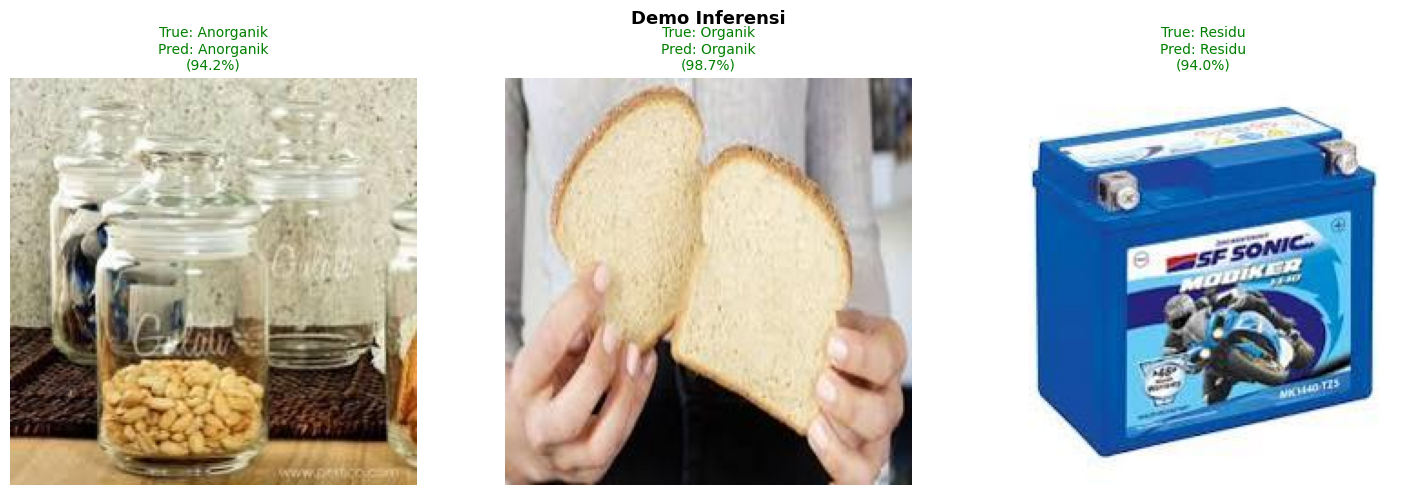

In [23]:
from tensorflow.keras.preprocessing import image as keras_image

# INTERFACE INI TIDAK BOLEH DIUBAH — dipakai backend aplikasi
def classify_image(img_path, top_k=3):
    """Klasifikasi gambar sampah.

    Args:
        img_path: Path ke file gambar
        top_k   : Jumlah prediksi teratas yang ditampilkan

    Returns:
        dict berisi predicted_class, confidence, dan top_predictions
    """
    # Load & preprocess — SAMA dengan backend
    img = keras_image.load_img(img_path, target_size=IMG_SIZE)
    img_array = keras_image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    prediction = model_final.predict(img_array, verbose=0)[0]
    predicted_idx   = int(np.argmax(prediction))
    predicted_class = CLASS_NAMES[predicted_idx]
    confidence      = float(prediction[predicted_idx] * 100)

    top_indices     = np.argsort(prediction)[::-1][:top_k]
    top_predictions = [(CLASS_NAMES[i], float(prediction[i] * 100)) for i in top_indices]

    return {
        'predicted_class': predicted_class,
        'confidence'     : confidence,
        'top_predictions': top_predictions
    }


# ─── Demo: cari gambar test secara otomatis ───────────────────────────────────
demo_results = []
for cls in CLASS_NAMES:
    cls_dir = os.path.join(TEST_DIR, cls)
    if os.path.exists(cls_dir):
        imgs = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        if imgs:
            demo_results.append((cls, os.path.join(cls_dir, imgs[0])))

fig, axes = plt.subplots(1, len(demo_results), figsize=(5 * len(demo_results), 5))
if len(demo_results) == 1:
    axes = [axes]

for ax, (true_cls, img_path) in zip(axes, demo_results):
    result = classify_image(img_path)
    img_show = keras_image.load_img(img_path, target_size=(224, 224))
    ax.imshow(img_show)
    ax.set_title(
        f"True: {true_cls}\nPred: {result['predicted_class']}\n({result['confidence']:.1f}%)",
        fontsize=10,
        color='green' if true_cls == result['predicted_class'] else 'red'
    )
    ax.axis('off')
    print(f"[{true_cls}] → {result}")

plt.suptitle('Demo Inferensi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 16. Simpan Model & Verifikasi Kompatibilitas

Verifikasi bahwa model final **100% kompatibel** dengan aplikasi yang sudah ada.


In [24]:
print("="*60)
print("  VERIFIKASI KOMPATIBILITAS DENGAN APLIKASI")
print("="*60)

# Verifikasi input shape
assert model_final.input_shape == (None, 224, 224, 3), " Input shape berubah!"
print(f" Input shape  : {model_final.input_shape}  (sama dengan aplikasi)")

# Verifikasi output shape
assert model_final.output_shape == (None, 3), " Output shape berubah!"
print(f" Output shape : {model_final.output_shape} (3 kelas — sama)")

# Verifikasi urutan class names
expected = ['Anorganik', 'Organik', 'Residu']
assert CLASS_NAMES == expected, f" Urutan class_names berubah! Got {CLASS_NAMES}"
print(f" Class names  : {CLASS_NAMES} (urutan sama)")

# Verifikasi nama file model
model_path = os.path.join('models', MODEL_FINAL)
assert os.path.exists(model_path), " File model tidak ditemukan!"
size_mb = os.path.getsize(model_path) / (1024 * 1024)
print(f" File model   : {MODEL_FINAL} ({size_mb:.1f} MB)")

# Test load ulang
reloaded = tf.keras.models.load_model(model_path, custom_objects={'FocalLoss': FocalLoss})
test_input = np.zeros((1, 224, 224, 3), dtype=np.float32)
test_out   = reloaded.predict(test_input, verbose=0)
assert test_out.shape == (1, 3), " Output shape setelah reload tidak sesuai!"
print(f" Reload test  : output shape {test_out.shape} ✓")

print("\n" + "="*60)
print("  SEMUA VERIFIKASI LULUS — Model siap deploy ke aplikasi")
print("="*60)


  VERIFIKASI KOMPATIBILITAS DENGAN APLIKASI
 Input shape  : (None, 224, 224, 3)  (sama dengan aplikasi)
 Output shape : (None, 3) (3 kelas — sama)
 Class names  : ['Anorganik', 'Organik', 'Residu'] (urutan sama)
 File model   : model_trashid_v3.keras (27.1 MB)
 Reload test  : output shape (1, 3) ✓

  SEMUA VERIFIKASI LULUS — Model siap deploy ke aplikasi


## 17. Cara Menjalankan TensorBoard

Log training sudah tersimpan di folder `logs/`. Jalankan perintah berikut di terminal:

```bash
tensorboard --logdir logs
```

Lalu buka browser di `http://localhost:6006`.

**Tab yang tersedia:**
- **Scalars** — kurva accuracy & loss semua stage (Stage 1, Stage 2, GradientTape)
- **Graphs** — arsitektur model
- **Histograms** — distribusi weights per epoch


In [25]:
import subprocess, sys

print(" TensorBoard Log Directories:")
for d in sorted(os.listdir('logs')):
    full = os.path.join('logs', d)
    if os.path.isdir(full):
        n_files = sum(len(f) for _, _, f in os.walk(full))
        print(f"   logs/{d}  ({n_files} event files)")

print("\n Jalankan: tensorboard --logdir logs")

# Otomatis load TensorBoard jika berjalan di Jupyter / Colab
try:
    get_ipython   # noqa
    # %load_ext tensorboard
    # %tensorboard --logdir logs
    print("   Di Jupyter, jalankan sel berikut:")
    print("   %load_ext tensorboard")
    print("   %tensorboard --logdir logs")
except NameError:
    pass


 TensorBoard Log Directories:
   logs/20260603-003213  (2 event files)
   logs/20260603-003213_gradienttape  (1 event files)
   logs/20260603-003213_stage2  (2 event files)

 Jalankan: tensorboard --logdir logs
   Di Jupyter, jalankan sel berikut:
   %load_ext tensorboard
   %tensorboard --logdir logs
